<a href="https://colab.research.google.com/github/Rancor06/Salman-Inten-Projects/blob/main/Phase%202/Day%2016/Day_16_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Task 1: Prepare Dataset
from google.colab import files
uploaded = files.upload()

Saving Dataset.zip to Dataset.zip
unzip:  cannot find or open your_dataset.zip, your_dataset.zip.zip or your_dataset.zip.ZIP.
find: ‘vehicle_dataset’: No such file or directory


In [7]:
!rm -rf vehicle_dataset
!unzip -q -o Dataset.zip -d vehicle_dataset

!find vehicle_dataset -maxdepth 4 -type d

vehicle_dataset
vehicle_dataset/Dataset
vehicle_dataset/Dataset/Vehicle
vehicle_dataset/Dataset/Vehicle/Bikes
vehicle_dataset/Dataset/Vehicle/Auto Rickshaws
vehicle_dataset/Dataset/Vehicle/Motorcycles
vehicle_dataset/Dataset/Vehicle/Cars


In [8]:
# Task 2: Build the CNN Model

import tensorflow as tf
from tensorflow.keras import layers, models

# --- Load and split the dataset directly from folders
img_size = (128, 128)
batch_size = 32
data_dir = "vehicle_dataset/Dataset/Vehicle"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes found:", class_names)
num_classes = len(class_names)

# --- Normalize pixel values (0-255 -> 0-1) ---
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Improve performance with caching/prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# --- Build the CNN ---
model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),   # Input Layer

    layers.Conv2D(32, (3, 3), activation='relu'),          # Conv2D Layer 1
    layers.MaxPooling2D((2, 2)),                            # MaxPooling Layer 1

    layers.Conv2D(64, (3, 3), activation='relu'),           # Conv2D Layer 2
    layers.MaxPooling2D((2, 2)),                            # MaxPooling Layer 2

    layers.Conv2D(128, (3, 3), activation='relu'),          # Conv2D Layer 3
    layers.MaxPooling2D((2, 2)),                            # MaxPooling Layer 3

    layers.Flatten(),                                       # Flatten Layer
    layers.Dense(128, activation='relu'),                   # Dense Layer
    layers.Dropout(0.5),                                    # Dropout (prevents overfitting)
    layers.Dense(num_classes, activation='softmax')         # Output Layer (4 classes)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Found 3190 files belonging to 4 classes.
Using 2552 files for training.
Found 3190 files belonging to 4 classes.
Using 638 files for validation.
Classes found: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5474 - loss: 1.0606 - val_accuracy: 0.7790 - val_loss: 0.5709
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7931 - loss: 0.5611 - val_accuracy: 0.8542 - val_loss: 0.4048
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8460 - loss: 0.4070 - val_accuracy: 0.8762 - val_loss: 0.3283
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8703 - loss: 0.3393 - val_accuracy: 0.8887 - val_loss: 0.3218
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9028 - loss: 0.2555 - val_accuracy: 0.8856 - val_loss: 0.2985
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9244 - loss: 0.2074 - val_accuracy: 0.9028 - val_loss: 0.2706
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9338 - loss: 0.1826 - val_accuracy: 0.9107 - val_loss: 0.2605
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9514 - loss: 0.1460 - val_accuracy: 0.8997 - val_los

Model saved as vehicle_cnn_model.h5


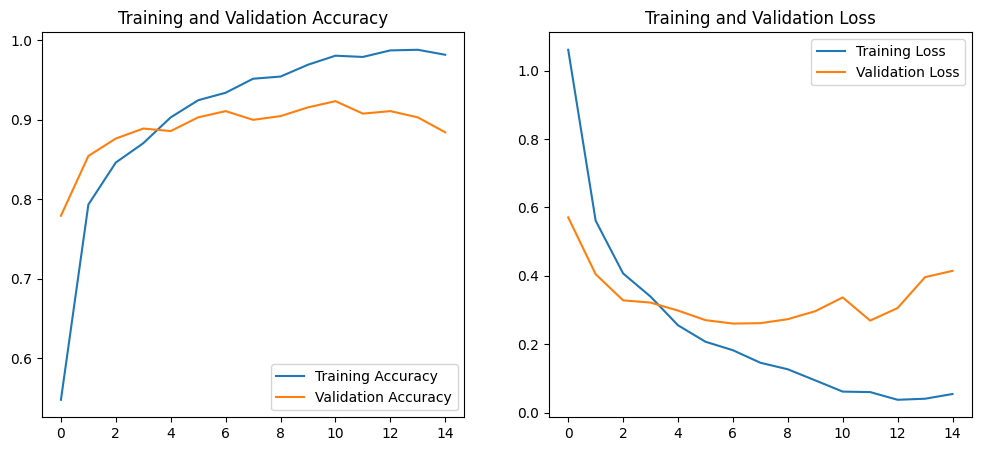

In [9]:
# Task 3: Train the CNN model

epochs = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# Save the trained model
model.save("vehicle_cnn_model.h5")
print("Model saved as vehicle_cnn_model.h5")

# Plot training/validation accuracy and loss
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [10]:
# Task 4: Evaluate the model on the validation/test set

test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Check for overfitting/underfitting by comparing final train vs val metrics
final_train_acc = acc[-1]
final_val_acc = val_acc[-1]
final_train_loss = loss[-1]
final_val_loss = val_loss[-1]

print(f"\nFinal Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

gap = final_train_acc - final_val_acc
if gap > 0.1:
    print("\n⚠️ Model appears to be OVERFITTING (train accuracy much higher than validation accuracy).")
elif final_train_acc < 0.6 and final_val_acc < 0.6:
    print("\n⚠️ Model appears to be UNDERFITTING (both train and validation accuracy are low).")
else:
    print("\n✅ Model appears to be reasonably well-fit.")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.8840 - loss: 0.4146
Test Accuracy: 88.40%
Test Loss: 0.4146

Final Training Accuracy: 98.16%
Final Validation Accuracy: 88.40%
Final Training Loss: 0.0547
Final Validation Loss: 0.4146

✅ Model appears to be reasonably well-fit.


Saving motorcycle1.jpg to motorcycle1.jpg
Saving bike1.jpg to bike1.jpg
Saving car2.jpg to car2.jpg
Saving car1.jpg to car1.jpg
Saving auto_rickshaw1.jpg to auto_rickshaw1.jpg
custom_test_images/auto_rickshaw1.jpg -> Predicted: Cars (90.6% confidence)
custom_test_images/bike1.jpg -> Predicted: Bikes (100.0% confidence)
custom_test_images/car1.jpg -> Predicted: Cars (99.9% confidence)
custom_test_images/motorcycle1.jpg -> Predicted: Motorcycles (99.9% confidence)
custom_test_images/car2.jpg -> Predicted: Cars (100.0% confidence)


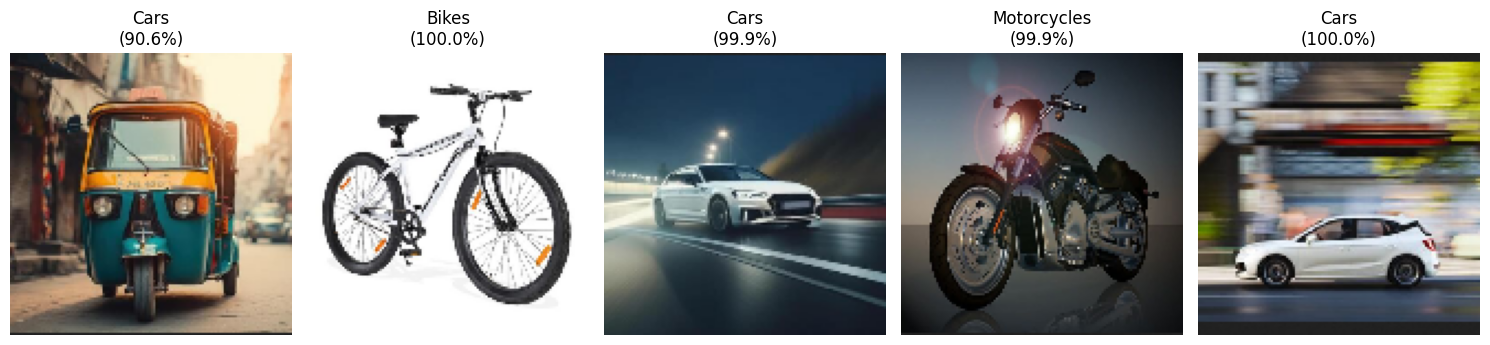

In [11]:
# Task 5: Test the model with custom vehicle images

# --- Upload 5 custom images ---
import os
os.makedirs("custom_test_images", exist_ok=True)

from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, f"custom_test_images/{filename}")

# --- Run predictions ---
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

test_image_paths = [
    "custom_test_images/auto_rickshaw1.jpg",
    "custom_test_images/bike1.jpg",
    "custom_test_images/car1.jpg",
    "custom_test_images/motorcycle1.jpg",
    "custom_test_images/car2.jpg",
]

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(test_image_paths):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.subplot(1, len(test_image_paths), i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class}\n({confidence:.1f}%)")
    plt.axis('off')

    print(f"{img_path} -> Predicted: {predicted_class} ({confidence:.1f}% confidence)")

plt.tight_layout()
plt.show()